![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

# Visual Document Classifier Lilt

## Blogposts and videos

- [Text Detection in Spark OCR](https://medium.com/spark-nlp/text-detection-in-spark-ocr-dcd8002bdc97)

- [Table Detection & Extraction in Spark OCR](https://medium.com/spark-nlp/table-detection-extraction-in-spark-ocr-50765c6cedc9)

- [Extract Tabular Data from PDF in Spark OCR](https://medium.com/spark-nlp/extract-tabular-data-from-pdf-in-spark-ocr-b02136bc0fcb)

- [Signature Detection in Spark OCR](https://medium.com/spark-nlp/signature-detection-in-spark-ocr-32f9e6f91e3c)

- [GPU image pre-processing in Spark OCR](https://medium.com/spark-nlp/gpu-image-pre-processing-in-spark-ocr-3-1-0-6fc27560a9bb)

- [How to Setup Spark OCR on UBUNTU - Video](https://www.youtube.com/watch?v=cmt4WIcL0nI)


**More examples here**

https://github.com/JohnSnowLabs/spark-ocr-workshop

**setup**

In [1]:
from johnsnowlabs import *

import json
import os
import pyspark
import sparkocr
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

spark = start_spark()
print("Spark OCR Version :", sparkocr.version())

📋 Loading license number 0 from /home/ubuntu/.johnsnowlabs/licenses/license_number_{number}_for_Spark-Healthcare.json


26/03/30 11:25:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


👌 Launched cpu optimized session with with: 🚀Spark-NLP==6.3.2, 💊Spark-Healthcare==6.3.0, 🕶Spark-OCR==6.3.0, running on ⚡ PySpark==3.4.0
Spark OCR Version : 6.3.0


## Load test images

In [3]:
import pkg_resources
test_image_path = pkg_resources.resource_filename(
    'sparkocr',
    'resources/ocr/visualdoc/00556614_00556648.tif'
)

bin_df = spark.read.format("binaryFile").load(test_image_path)

bin_df.show()

+--------------------+--------------------+------+--------------------+
|                path|    modificationTime|length|             content|
+--------------------+--------------------+------+--------------------+
|file:/home/ubuntu...|2026-02-09 09:23:...|375950|[49 49 2A 00 B8 B...|
+--------------------+--------------------+------+--------------------+



## Display images


    Image #0:
    Origin: file:/home/ubuntu/.local/lib/python3.10/site-packages/sparkocr/resources/ocr/visualdoc/00556614_00556648.tif
    Resolution: 72 dpi
    Width: 784 px
    Height: 1000 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


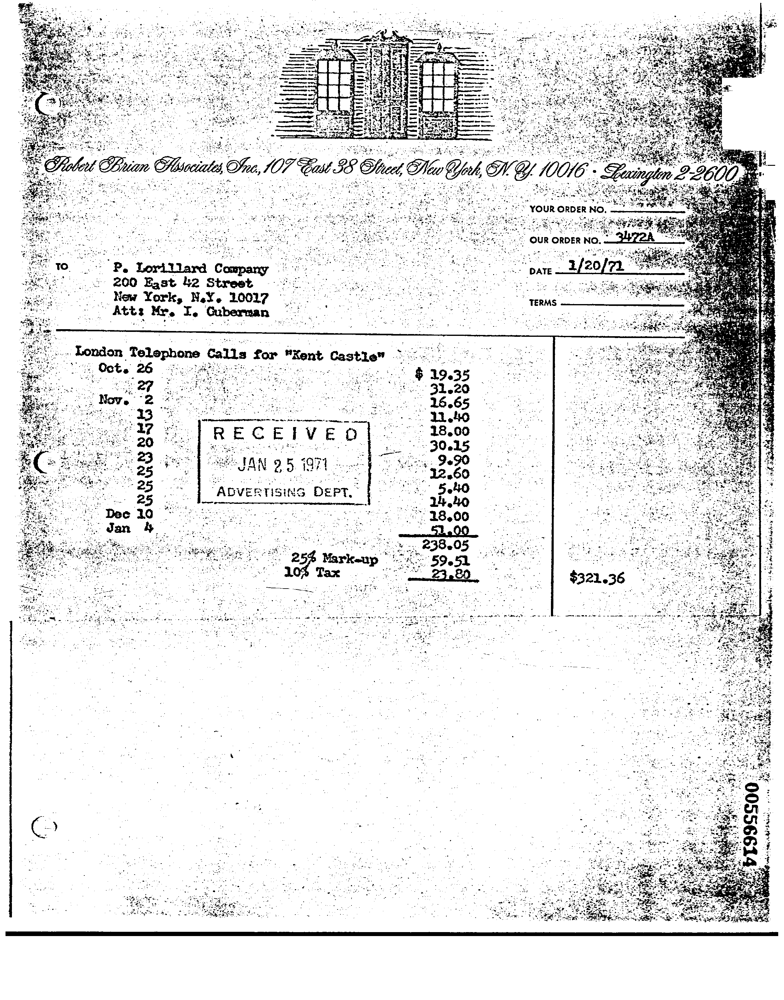

In [4]:
image_df = visual.BinaryToImage().transform(bin_df)
visual.display_images(image_df)

### Define pipeline

In [5]:
from sparkocr.utils import get_vocabulary_dict
from pyspark.ml import PipelineModel

binary_to_image = visual.BinaryToImage()\
    .setOutputCol("image") \
    .setImageType(visual.ImageType.TYPE_3BYTE_BGR)

img_to_hocr = visual.ImageToHocr()\
    .setInputCol("image")\
    .setOutputCol("hocr")\
    .setIgnoreResolution(False)\
    .setOcrParams(["preserve_interword_spaces=0"])

doc_class = visual.VisualDocumentClassifierLilt() \
    .pretrained("lilt_rvl_cdip_296K", "en", "clinical/ocr") \
    .setInputCol("hocr") \
    .setOutputCol("label")

# OCR pipeline
pipeline = PipelineModel(stages=[
    binary_to_image,
    img_to_hocr,
    doc_class
])

lilt_rvl_cdip_296K download started this may take some time.
Approximate size to download 412.4 MB
Download done! Loading the resource.


## Call pipeline

In [6]:
results = pipeline.transform(bin_df).cache()

## Show results

In [7]:
results.select(["label"]) \
    .show(50, truncate=False)


Detected 39 diacritics
[Stage 4:>                                                          (0 + 1) / 1]

+-------+
|label  |
+-------+
|invoice|
+-------+

